In [ ]:
### https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/saltandpepper_Screen Shot 2018-06-12 at 8.53.54 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/Screen Shot 2018-06-12 at 9.27.26 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_45_Screen Shot 2018-06-12 at 8.58.13 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.47.41 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.56.30 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/saltandpepper_Screen Shot 2018-06-12 at 9.11.17 PM.png
/kaggle/input/datasets/sriramr/fruit

In [2]:
import os

# Walk through the input directory to see your dataset folders
for root, dirs, files in os.walk('/kaggle/input'):
    print(f"Directory: {root}")

    if files:
        print(f"Sample Files: {files[:2]}\n")
        break

Directory: /kaggle/input
Directory: /kaggle/input/datasets
Directory: /kaggle/input/datasets/sriramr
Directory: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification
Directory: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset
Directory: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset
Directory: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test
Directory: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana
Sample Files: ['saltandpepper_Screen Shot 2018-06-12 at 8.53.54 PM.png', 'Screen Shot 2018-06-12 at 9.27.26 PM.png']



In [3]:
import os

# Let's see exactly how Kaggle arranged the folders
for root, dirs, files in os.walk('/kaggle/input'):
    if 'test' in root or 'train' in root:
        print(f"Found path: {root}")

Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshoranges
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenoranges
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshbanana
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenapples
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshapples
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/train
Found path: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten

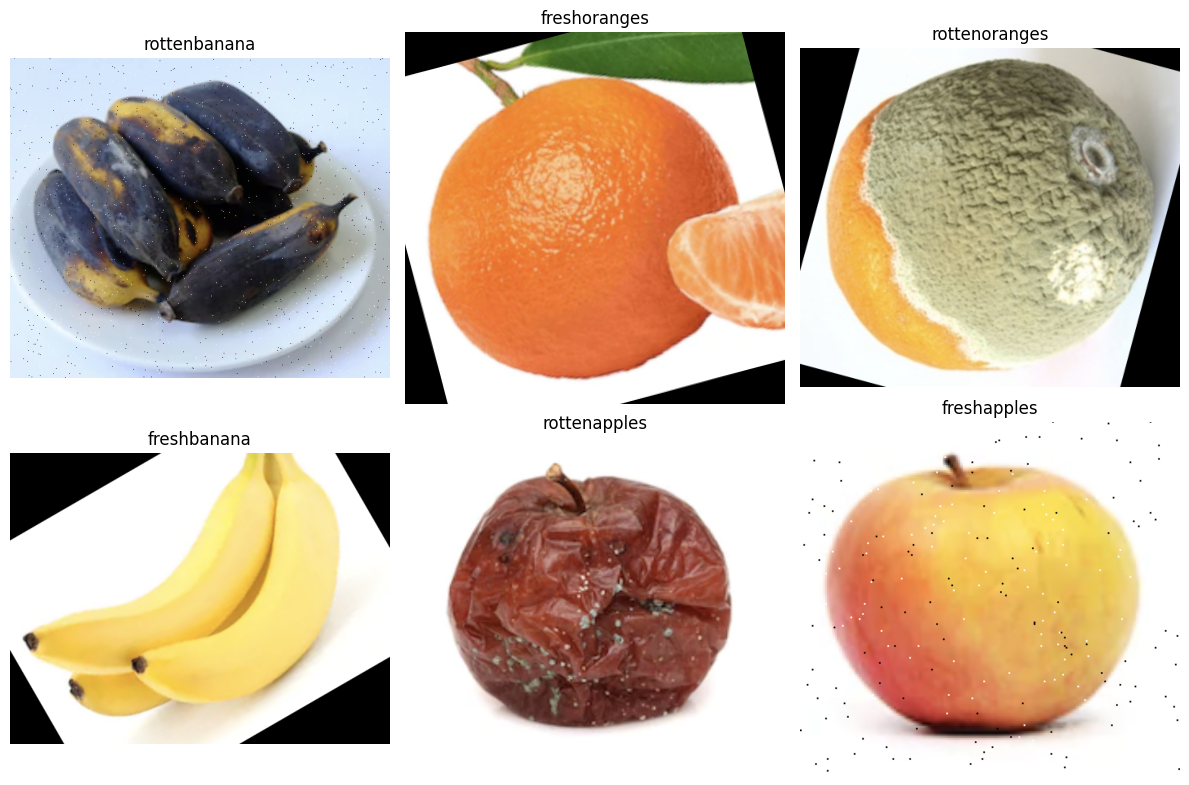

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

base_path = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test"

# First 6 celebrity folders
first_6_images = [
    os.path.join(base_path, folder)
    for folder in os.listdir(base_path)[:6]
]

# Load the first image from each folder
images = []
labels = []

for folder in first_6_images:
    first_image = os.listdir(folder)[0]
    img_path = os.path.join(folder, first_image)

    images.append(np.array(Image.open(img_path)))
    labels.append(os.path.basename(folder))

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
labels = sorted(os.listdir(base_path))
print(labels)
print("Category Count :", len(labels))

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Category Count : 6


freshapples: 395
freshbanana: 381
freshoranges: 388
rottenapples: 601
rottenbanana: 530
rottenoranges: 403


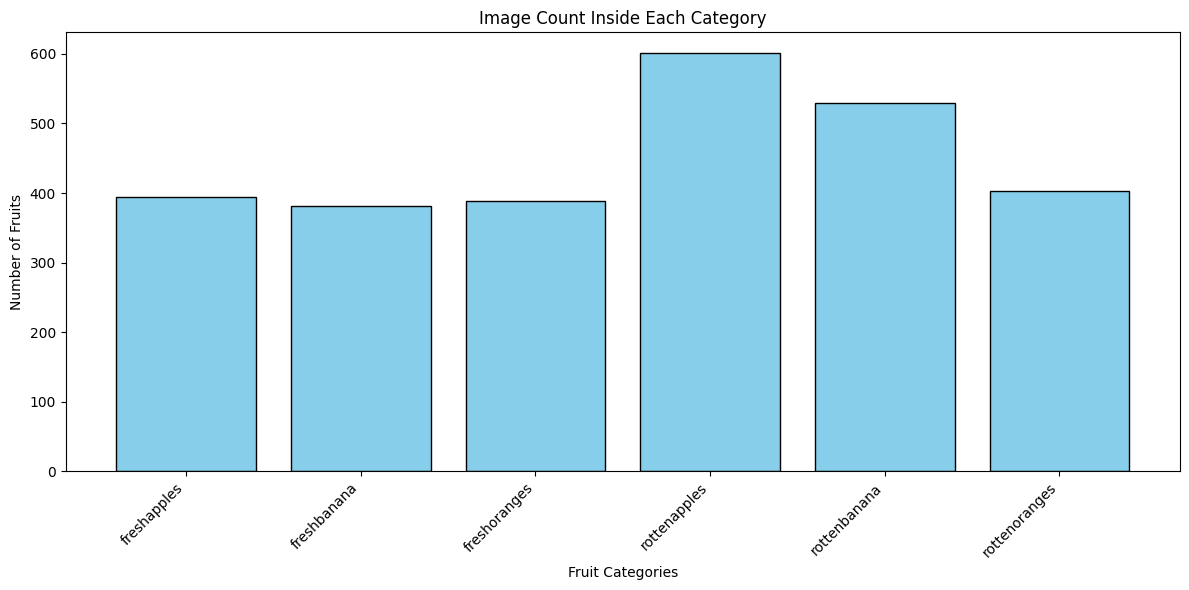

In [6]:
import os
import matplotlib.pyplot as plt

# FIX: Point to the main test folder containing all fruit subfolders
base_path = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test"

labels = []
counts = []

for category in sorted(os.listdir(base_path)):
    category_path = os.path.join(base_path, category)

    # This will now successfully find folders like 'freshapples', 'rottenbanana', etc.
    if os.path.isdir(category_path):
        labels.append(category)
        count = len(os.listdir(category_path))
        counts.append(count)
        print(f"{category}: {count}")

plt.figure(figsize=(12,6))
plt.bar(labels, counts, color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha="right")
plt.xlabel("Fruit Categories")  # Fixed label
plt.ylabel("Number of Fruits")
plt.title("Image Count Inside Each Category")
plt.tight_layout()
plt.show()

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [8]:
base_model = EfficientNetB0(
    weights='imagenet', 
    include_top=False,     # Excludes the final 1000-class layer so you can add your own
    input_shape=(224, 224, 3)
)



I0000 00:00:1783492550.451756      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783492550.454666      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

# 1. Initialize your Sequential model
model = Sequential()

# 2. Add your EfficientNet base (which we called base_model earlier)
model.add(base_model)

# 3. Use Global Average Pooling instead of Flatten (Highly recommended for EfficientNet)
model.add(GlobalAveragePooling2D())

# 4. Dense hidden layer for learning custom features
model.add(Dense(128, activation='relu'))

# 5. Dropout to prevent overfitting 
model.add(Dropout(0.2))  # Bumped slightly to 0.2 for better regularization

# 6. Final output layer tailored exactly to your 6 fruit classes
model.add(Dense(6, activation='softmax'))

# View the clean network structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 4,172,290 (15.92 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [10]:
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer True
rescaling True
normalization True
rescaling_1 True
stem_conv_pad True
stem_conv True
stem_bn True
stem_activation True
block1a_dwconv True
block1a_bn True
block1a_activation True
block1a_se_squeeze True
block1a_se_reshape True
block1a_se_reduce True
block1a_se_expand True
block1a_se_excite True
block1a_project_conv True
block1a_project_bn True
block2a_expand_conv True
block2a_expand_bn True
block2a_expand_activation True
block2a_dwconv_pad True
block2a_dwconv True
block2a_bn True
block2a_activation True
block2a_se_squeeze True
block2a_se_reshape True
block2a_se_reduce True
block2a_se_expand True
block2a_se_excite True
block2a_project_conv True
block2a_project_bn True
block2b_expand_conv True
block2b_expand_bn True
block2b_expand_activation True
block2b_dwconv True
block2b_bn True
block2b_activation True
block2b_se_squeeze True
block2b_se_reshape True
block2b_se_reduce True
block2b_se_expand True
block2b_se_excite True
block2b_project_conv True
block2b_project_bn True
b

In [11]:
# Unfreeze the convolutional base
base_model.trainable = True

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only Block 5
for layer in base_model.layers:
    if layer.name.startswith("block7"):
        layer.trainable = True
    

In [12]:
import os
import shutil
from sklearn.model_selection import train_test_split

base_path = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test"

# New dataset location
output_root = "fruits_ripe_vs_rot"
train_path = os.path.join(output_root, "Train")
test_path = os.path.join(output_root, "Test")

# Remove old split if it exists
if os.path.exists(output_root):
    shutil.rmtree(output_root)

os.makedirs(train_path)
os.makedirs(test_path)

for category in sorted(os.listdir(base_path)):
    category_path = os.path.join(base_path, category)

    if not os.path.isdir(category_path):
        continue

    images = [
        os.path.join(category_path, img)
        for img in os.listdir(category_path)
    ]

    train_imgs, test_imgs = train_test_split(
        images,
        test_size=0.2,
        random_state=42
    )

    train_class = os.path.join(train_path, category)
    test_class = os.path.join(test_path, category)

    os.makedirs(train_class, exist_ok=True)
    os.makedirs(test_class, exist_ok=True)

    for img in train_imgs:
        shutil.copy(img, os.path.join(train_class, os.path.basename(img)))

    for img in test_imgs:
        shutil.copy(img, os.path.join(test_class, os.path.basename(img)))

    print(f"{category:25s} Train: {len(train_imgs):3d}  Test: {len(test_imgs):3d}")

print("\nDone!")
print(output_root)

freshapples               Train: 316  Test:  79
freshbanana               Train: 304  Test:  77
freshoranges              Train: 310  Test:  78
rottenapples              Train: 480  Test: 121
rottenbanana              Train: 424  Test: 106
rottenoranges             Train: 322  Test:  81

Done!
fruits_ripe_vs_rot


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
  
# Data augmentation for the training dataset
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,      # Normalize pixel values to [0, 1]
    rotation_range=20,      # Randomly rotate images up to ±20°
    zoom_range=0.2,         # Randomly zoom in/out
    horizontal_flip=True,   # Randomly flip images horizontally
    fill_mode="nearest"     # Fill newly created pixels after transformations
)

# No augmentation for the test dataset
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [14]:
# # Load the training dataset
# train_generator = train_datagen.flow_from_directory(
#     directory=r"/kaggle/working/fruits_ripe_vs_rot/Train",
#     target_size=(224,224),
#     batch_size=75,
#     class_mode="categorical",
#     shuffle=True
# )

# # Load the testing dataset
# test_generator = test_datagen.flow_from_directory(
#     directory=r"/kaggle/working/fruits_ripe_vs_rot/Test",
#     target_size=(224,224),
#     batch_size=75,
#     class_mode="categorical",
#     shuffle=False
# )
import tensorflow as tf

# Define directory paths 
train_dir = '/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test'
test_dir = '/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test'

# Load Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,       # Automatically takes 20% of training data for Validation
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'    # Matches 'categorical_crossentropy' loss
)

# Load Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# Load Test Data (Separate evaluation dataset)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False               # Keep False to easily match predictions to actual names later
)

Found 2698 files belonging to 6 classes.
Using 2159 files for training.
Found 2698 files belonging to 6 classes.
Using 539 files for validation.
Found 2698 files belonging to 6 classes.


In [15]:
from keras.optimizers import Adam
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Use 'sparse_categorical_crossentropy' if your data generator labels are integers
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 881,974 (3.36 MB)

 Non-trainable params: 3,332,339 (12.71 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor="val_loss",
#     min_delta=0.001,
#     patience=3,
#     restore_best_weights=True,
#     verbose=1
# )


# # Train the model
# history = model.fit(
#     train_generator,
#     epochs=15,
#     validation_data=test_generator,
#     callbacks=[early_stopping],
#     verbose=1
# )
early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=3,
    restore_best_weights=True,
    verbose=1
)
# Train the model for 5-10 epochs (EfficientNet reaches high accuracy very quickly)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[early_stopping],
    epochs=10
)

Epoch 1/10


2026-07-08 06:36:39.445906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:36:39.590235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:36:39.940734: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:36:40.083747: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:36:40.912433: E external/local_xla/xla/stream_

66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8223 - loss: 0.5541

2026-07-08 06:37:01.275521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:01.413727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:01.744924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:01.890251: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:02.035344: E external/local_xla/xla/stream_

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.8254 - loss: 0.5450

2026-07-08 06:37:25.991321: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:26.134469: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:26.477482: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:26.620170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:37:27.397672: E external/local_xla/xla/stream_

68/68 ━━━━━━━━━━━━━━━━━━━━ 73s 612ms/step - accuracy: 0.9273 - loss: 0.2427 - val_accuracy: 0.9870 - val_loss: 0.0508
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9917 - loss: 0.0283 - val_accuracy: 0.9870 - val_loss: 0.0619
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9935 - loss: 0.0208 - val_accuracy: 0.9944 - val_loss: 0.0210
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9903 - loss: 0.0276 - val_accuracy: 0.9944 - val_loss: 0.0318
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9981 - loss: 0.0078 - val_accuracy: 0.9926 - val_loss: 0.0429
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9981 - loss: 0.0049 - val_accuracy: 0.9926 - val_loss: 0.0420
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [17]:
# Evaluate loss and accuracy on testing data
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9978 - loss: 0.0100

2026-07-08 06:38:03.799176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:38:03.937435: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:38:04.265956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:38:04.407658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 06:38:04.549301: E external/local_xla/xla/stream_

85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step - accuracy: 0.9985 - loss: 0.0059
Test Loss: 0.0059
Test Accuracy: 99.85%


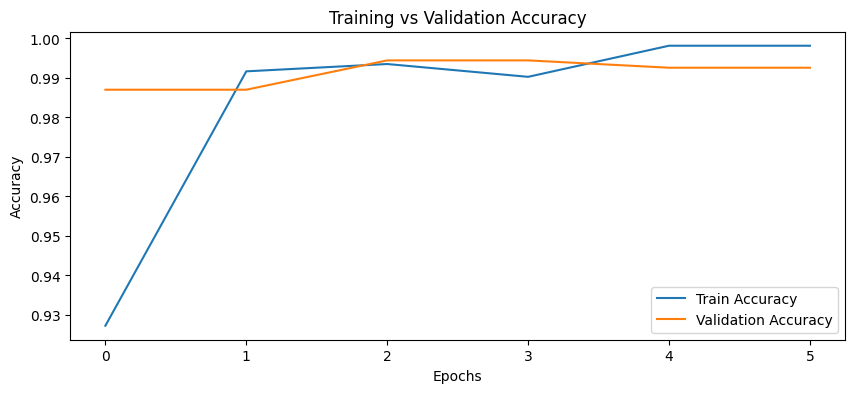

In [18]:
import matplotlib.pyplot as plt

# Plot Accuracy curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Generating predictions on test data...

================ CLASSIFICATION REPORT ================
               precision    recall  f1-score   support

  freshapples       1.00      1.00      1.00       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       1.00      0.99      1.00       388
 rottenapples       1.00      1.00      1.00       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       1.00      1.00      1.00       403

     accuracy                           1.00      2698
    macro avg       1.00      1.00      1.00      2698
 weighted avg       1.00      1.00      1.00      2698



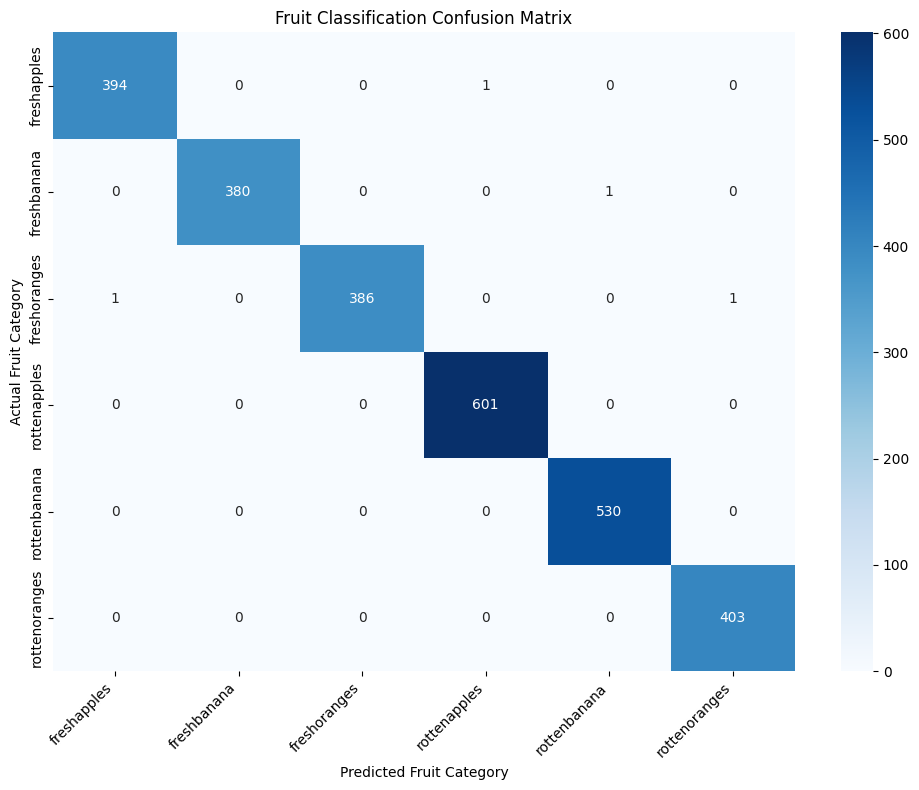

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get true labels and model predictions from the test dataset
print("Generating predictions on test data...")
y_true = []
y_pred = []

# Loop through test dataset to collect actuals and predictions
for images, labels in test_ds:
    # Get true class indices
    true_indices = np.argmax(labels.numpy(), axis=1)
    y_true.extend(true_indices)
    
    # Get predicted class indices from the model
    preds = model.predict(images, verbose=0)
    pred_indices = np.argmax(preds, axis=1)
    y_pred.extend(pred_indices)

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Get class names from the dataset automatically
class_names = test_ds.class_names

# 3. Print the text report (Precision, Recall, F1-Score per class)
print("\n================ CLASSIFICATION REPORT ================")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Generate and plot a beautiful Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Fruit Classification Confusion Matrix')
plt.ylabel('Actual Fruit Category')
plt.xlabel('Predicted Fruit Category')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
import gradio as gr
from PIL import Image

# 1. Define the exact class names (make sure these match the order of your dataset folders!)
class_names = ['freshapples', 'freshbananas', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']

# 2. Your updated prediction function
def predict_fruit_condition(img):
    img = img.convert('RGB').resize((224, 224))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)[0]
    
    # This will now work perfectly because 'class_names' exists!
    return {class_names[i]: float(prediction[i]) for i in range(len(class_names))}

# def predict_fruit_condition(img):
#     # FIX: Use the actual dimensions (224, 224) directly instead of img_size
#     img = img.convert('RGB').resize((224, 224))
    
#     # Convert PIL image to numpy array for the model
#     img_array = np.array(img)
#     img_array = np.expand_dims(img_array, axis=0)
    
#     # ... rest of your prediction code ...
#     prediction = model.predict(img_array)[0]
    
#     # Return your class mappings dictionary
#     return {class_names[i]: float(prediction[i]) for i in range(len(class_names))}
demo = gr.Interface(
    fn=predict_fruit_condition,
    inputs=gr.Image(type='pil', label='Upload a celebrity face'),
    outputs=gr.Label(num_top_classes=5, label='Top-5 Predictions'),
    title='Fruits State Classifier (EfficientNetB0 Transfer Learning)',
    description=(
        'Upload an image of one of the 3 fruits in the dataset '
        'and the model will predict which of it is fresh or rotten along with a confidence score.'
    ),
    flagging_mode='never'
)

demo.launch(debug=False)

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://78d4009f9f2cdd08e0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
